# **Preparation Notebook**



---
## Setup Environment

In [1]:
# DO NOT MODIFY THE CODE IN THIS CELL
!pip install -q utstd

from utstd.folders import *
from utstd.ipyrenders import *

at = AtFolder(
    course_code=36106,
    assignment="AT3",
)
at.run()

import warnings
warnings.simplefilter(action='ignore')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.9/12.9 MB 40.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 50.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
umap-learn 0.5.12 requires scikit-learn>=1.6, but you have scikit-learn 1.5.2 which is incompatible.
hdbscan 0.8.42 requires scikit-learn>=1.6, but you have scikit-learn 1.5.2 which is incompatible.
Mounted at /content/gdrive

You can now save your data files in: /content/gdrive/MyDrive/36106/assignment/AT3/data


---
## Student Information

In [2]:
# <Student to fill this section>
group_name = "Group 20"
student_name = "Ratnadeep Patra"
student_id = "26294153"

In [3]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h1", key='group_name', value=group_name)

In [4]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h1", key='student_name', value=student_name)

In [5]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h1", key='student_id', value=student_id)

---
## 0. Python Packages

### 0.a Install Additional Packages

> If you are using additional packages, you need to install them here using the command: `! pip install <package_name>`

In [6]:
# <Student to fill this section and then remove this comment>

### 0.b Import Packages

In [7]:
# DO NOT MODIFY THE CODE IN THIS CELL
import pandas as pd
import altair as alt

In [8]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from collections import defaultdict
import graphviz
from sklearn.preprocessing import StandardScaler
import pickle

In [9]:
pd.set_option('display.max_columns', None) # Forcing pandas to display all columns
pd.set_option('display.max_rows', None) # Forcing pandas to display all rows

---
## A. Feature Selection


## A.0 Load Data

In [10]:
# DO NOT MODIFY THE CODE IN THIS CELL
# Load datasets
try:
  customer_df = pd.read_csv(at.folder_path / "customer.csv")
  person_df = pd.read_csv(at.folder_path / "person.csv")
  product_category_df = pd.read_csv(at.folder_path / "product_category.csv")
  product_cost_history_df = pd.read_csv(at.folder_path / "product_cost_history.csv")
  product_list_price_history_df = pd.read_csv(at.folder_path / "product_list_price_history.csv")
  product_sub_category_df = pd.read_csv(at.folder_path / "product_sub_category.csv")
  product_df = pd.read_csv(at.folder_path / "product.csv")
  sales_order_detail_df = pd.read_csv(at.folder_path / "sales_order_detail.csv")
  sales_order_header_df = pd.read_csv(at.folder_path / "sales_order_header.csv")
  sales_territory_df = pd.read_csv(at.folder_path / "sales_territory.csv")
  special_offer_product_df = pd.read_csv(at.folder_path / "special_offer_product.csv")
  special_offer_df = pd.read_csv(at.folder_path / "special_offer.csv")
  store_df = pd.read_csv(at.folder_path / "store.csv")
  unit_measure_df = pd.read_csv(at.folder_path / "unit_measure.csv")
except Exception as e:
  print(e)

### A.1 Approach 1 "Merge required df"

In [11]:
df_dict = {
    "customer": customer_df,
    "person": person_df,
    "product_category": product_category_df,
    "product_cost_history": product_cost_history_df,
    "product_list_price_history": product_list_price_history_df,
    "product_sub_category": product_sub_category_df,
    "product": product_df,
    "sales_order_detail": sales_order_detail_df,
    "sales_order_header": sales_order_header_df,
    "sales_territory": sales_territory_df,
    "special_offer_product": special_offer_product_df,
    "special_offer": special_offer_df,
    "store": store_df,
    "unit_measure": unit_measure_df
}

In [12]:
pk_df_map = {
    "customer_id" : "customer",
    "person_id" : "person",
    "product_category_id" : "product_category",
    "product_subcategory_id" : "product_sub_category",
    "product_id" : "product",
    "sales_order_detail_id" : "sales_order_detail",
    "sales_order_id" : "sales_order_header",
    "sales_territory_id" : "sales_territory",
    "special_offer_id" : "special_offer",
    "store_id" : "store",
    "unit_measure_code" : "unit_measure",
    "size_unit_measure_code" : "unit_measure",
    "weight_unit_measure_code" : "unit_measure",
    "territory_id" : "sales_territory"
} # Identified from other EDA files

In [13]:
column_map = defaultdict(list)
for table_name, df in df_dict.items():
    for col in df.columns:
        column_map[col].append(table_name)

fk_relations = []
for col, tables in column_map.items():
    parent_table = None
    for t in tables:
        if col.lower() in pk_df_map.keys():
            parent_table = pk_df_map[col.lower()]
            break
    if parent_table is not None:
        for child_table in tables:
            if child_table != parent_table:
                fk_relations.append({
                    "child_table": child_table,
                    "parent_table": parent_table,
                    "fk_column": col
                })

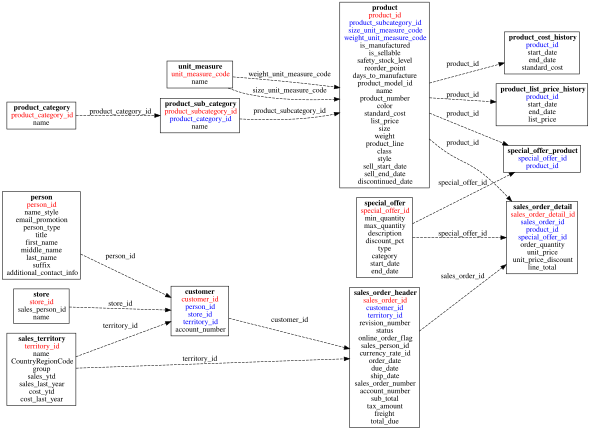

In [14]:
dot = graphviz.Digraph(
    comment='Entity Relationship Diagram',
    graph_attr={
        'rankdir': 'LR',
        'size': '10,6',
        'ratio': 'compress'})
for table_name, df in df_dict.items():
    pk_cols_for_table = {pk_col_name for pk_col_name, pk_table_name in pk_df_map.items() if pk_table_name == table_name}
    fk_cols_for_table = {rel['fk_column'] for rel in fk_relations if rel['child_table'] == table_name}
    current_table_pks = []
    current_table_fks = []
    current_table_others = []

    for col in df.columns.tolist():
        if col in pk_cols_for_table:
            current_table_pks.append(f'<FONT COLOR="red">{col}</FONT>')
        elif col in fk_cols_for_table:
            current_table_fks.append(f'<FONT COLOR="blue">{col}</FONT>')
        else:
            current_table_others.append(col)

    column_labels_formatted = current_table_pks + current_table_fks + current_table_others
    columns_html = '<br/>'.join(column_labels_formatted)
    label = f"<<B>{table_name}</B><br/>{columns_html}>"
    dot.node(table_name, label=label, shape='box')

for rel in fk_relations:
    dot.edge(rel['parent_table'],
             rel['child_table'],
             label=rel['fk_column'],
             style="dashed")

display(dot)

In [15]:
merged_sales_df = pd.merge(sales_order_detail_df, sales_order_header_df, on='sales_order_id', how='left')
merged_sales_df = pd.merge(merged_sales_df, special_offer_df, on='special_offer_id', how='left')
product_df.drop_duplicates(inplace=True) # As identified during EDA, product table has a lot of duplicates
merged_sales_df = pd.merge(merged_sales_df, product_df, on='product_id', how='left', suffixes=('', '_product'))
merged_sales_df = pd.merge(merged_sales_df, product_sub_category_df, on='product_subcategory_id', how='left', suffixes=('', '_subcategory'))
merged_sales_df = pd.merge(merged_sales_df, product_category_df, on='product_category_id', how='left', suffixes=('', '_category'))

In [16]:
len(merged_sales_df) == len(sales_order_detail_df)

True

In [17]:
# <Student to fill this section>
feature_selection_1_insights = """
The initial feature selection focused on merging the core tables required to study product-level sales behaviour and identify unusual sales patterns for
products (as per the buisness use case stated in Anomaly detection notebook). Peripheral tables such as 'person', 'store', and 'sales_territory' were
excluded to maintain focus on the immediate transactional and product-related attributes. History tables such as 'product_cost_history' and
'product_list_price_history' were also omitted to simplify the analysis and focus on the current sales structure. To handle overlapping column names across
joined tables, informative suffixes such as '_product' and '_category' were applied. This produced a flat analytical dataset suitable for inspecting
transaction-level and product-level features.
"""

In [18]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h3", key='feature_selection_1_insights', value=feature_selection_1_insights)

### A.2 Approach 2 "Drop ID columns"

In [19]:
feature_sel_df = merged_sales_df.copy()

In [20]:
id_cols = ['sales_order_id',
 'sales_order_detail_id',
 'product_id',
 'special_offer_id',
 'sales_person_id',
 'territory_id',
 'currency_rate_id',
 'product_category_id',
 'product_subcategory_id',
 'product_model_id',
 'sales_order_number',
 'customer_id',
 'account_number'
]

In [21]:
feature_sel_df.drop(id_cols, axis=1, inplace=True)

In [22]:
# <Student to fill this section>
feature_selection_2_insights = """
Identification columns such as 'sales_order_id', 'product_id', and 'customer_id' provide unique keys for database integrity but do not contain any signal
for statistical analysis. Keeping these features would lead to high-cardinality noise and potentially cause the model to focus on specific entity instances
rather than looking for generalizable patterns. 'account_number' is also considered an ID as it uniquely identifies a customer's billing account. By
removing these 13 ID-related columns, we reduce the dimensionality of the dataset and ensure the model focuses on meaningful attributes like price, quantity,
and product characteristics. Although 'customer_id' and 'account_number' are dropped currently, later, once an anomaly is detected, they can be again used
to identify the reason for that anomaly and further analysis around that can be done to check if the anomaly is specific to a customer or some specific
account number of a customer to get the root cause of that anomaly.
"""

In [23]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h3", key='feature_selection_2_insights', value=feature_selection_2_insights)

### A.3 Approach 3 "Drop constant value features"

In [24]:
feature_sel_df['is_sellable'].value_counts()

,count
is_sellable,
1.0,42100


In [25]:
constant_value_col = [
    'status',
    'is_sellable',
    'discontinued_date'
]

In [26]:
feature_sel_df.drop(constant_value_col, axis=1, inplace=True)

In [27]:
# <Student to fill this section>
feature_selection_3_insights = """
The features 'status', 'is_sellable', and 'discontinued_date' were removed due to their lack of variance, making them unsuitable for any ML algorithm.
During the EDA of the 'sales_order_header' table, it was observed that all samples contained a constant value of 5 for this column. A feature with a
single unique value provides no significant signals for any model. Similarly, for the 'is_sellable' column, each sample is having value 1 as all products
recorded in the sales data should be eligible to sell, rendering this feature constant and uninformative for predicting anomalies. The EDA of the 'product'
table revealed that the 'discontinued_date' column contained exclusively NaN values. A feature composed entirely of missing values carries no information.
"""

In [28]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h3", key='feature_selection_3_insights', value=feature_selection_3_insights)

### A.4 Approach 4 "Drop derived features"

In [29]:
feature_sel_df[
    feature_sel_df['total_due'].round(4) != (
        feature_sel_df['sub_total']
        + feature_sel_df['tax_amount']
        + feature_sel_df['freight']
    ).round(4)
][['sub_total', 'tax_amount', 'freight', 'total_due']]

,sub_total,tax_amount,freight,total_due


In [30]:
feature_sel_df['sales_order_id'] = merged_sales_df['sales_order_id']
sales_order_summary = feature_sel_df.groupby('sales_order_id').agg(
    sum_line_total=('line_total', 'sum'),
    sub_total=('sub_total', 'first')
).reset_index()
feature_sel_df.drop(['sales_order_id'], axis=1, inplace=True)
sales_order_summary[
    sales_order_summary['sum_line_total'].round(4) != sales_order_summary['sub_total'].round(4)
]

,sales_order_id,sum_line_total,sub_total
886,0e316b6d-d946-448b-8e64-07f058c7d4aa,28344.64305,28344.6431
1091,11bea793-bc5e-4af3-a3aa-1516829af0ae,38818.22895,38818.2290
1680,1c0fc492-c6ce-41bf-887c-9f32ae37354b,46703.15475,46703.1548
2041,22bc2384-1a25-4cfb-9222-b4c8ef3f0599,57771.76405,57771.7641
4673,4e81a9ac-a811-4ede-9d55-b84c553614e6,17746.25205,17746.2521
10622,b209b701-50e8-4d9f-b821-9c26b7300c92,8617.54965,8617.5497
10624,b2295f1d-1b7f-462d-b2e2-b3b62e2124d8,72301.95105,72301.9511
10762,b46c1a2f-fab3-45d6-838c-dca0a55b3a75,29331.50985,29331.5099
10818,b551303d-1a7c-4395-bc39-ee409a28c5da,39566.38465,39566.3847


In [31]:
sales_order_summary[
    ~np.isclose(sales_order_summary['sum_line_total'], sales_order_summary['sub_total'].round(4))
]

,sales_order_id,sum_line_total,sub_total


In [32]:
feature_sel_df[
    feature_sel_df['line_total'].round(4) != (
        feature_sel_df['order_quantity'] * feature_sel_df['unit_price'] * (1 - feature_sel_df['unit_price_discount'])
    ).round(4)
][['line_total', 'order_quantity', 'unit_price', 'unit_price_discount']]

,line_total,order_quantity,unit_price,unit_price_discount
2108,7364.02095,18.0,430.6445,0.05
5936,46.93095,18.0,2.7445,0.05
6077,564.03875,17.0,34.9250,0.05
7332,46.93095,18.0,2.7445,0.05
7591,46.93095,18.0,2.7445,0.05
18716,564.03875,17.0,34.9250,0.05
18912,84.55095,18.0,4.9445,0.05
31067,564.03875,17.0,34.9250,0.05


In [33]:
feature_sel_df[
    ~np.isclose(feature_sel_df['line_total'], (
        feature_sel_df['order_quantity'] * feature_sel_df['unit_price'] * (1 - feature_sel_df['unit_price_discount'])
    ))
][['line_total', 'order_quantity', 'unit_price', 'unit_price_discount']]

,line_total,order_quantity,unit_price,unit_price_discount


In [34]:
# total_due = sub_total + tax_amount + freight
# sub_total = sum(line_total)
# line_total = unit_price * order_quantity * (1 - unit_price_discount)

derived_features = [
    'total_due',
    'sub_total',
    'line_total'
]

In [35]:
feature_sel_df.drop(derived_features, axis=1, inplace=True)

In [36]:
# <Student to fill this section>
feature_selection_4_insights = """
Features such as 'total_due', 'sub_total', and 'line_total' are direct linear combinations of other existing features within the dataset. Since these
features can be precisely re-derived from more granular attributes, retaining them would introduce multicollinearity and redundancy without adding new
predictive information. By dropping these derived features, the dimensionality of the dataset is reduced, leading to a simpler and more efficient model
without any loss of crucial information. This approach ensures that the model focuses on the fundamental, independent variables.
"""

In [37]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h3", key='feature_selection_4_insights', value=feature_selection_4_insights)

### A.5 Approach 5 "Drop duplicate features"

In [38]:
feature_sel_df[feature_sel_df['discount_pct'] != feature_sel_df['unit_price_discount']][
    ['discount_pct', 'unit_price_discount', 'description', 'order_quantity', 'min_quantity']].sample(25, random_state=42)

,discount_pct,unit_price_discount,description,order_quantity,min_quantity
21006,0.02,0.0,Volume Discount 11 to 14,1.0,11.0
5341,0.02,0.0,Volume Discount 11 to 14,1.0,11.0
23132,0.02,0.0,Volume Discount 11 to 14,1.0,11.0
32801,0.02,0.0,Volume Discount 11 to 14,1.0,11.0
4448,0.02,0.0,Volume Discount 11 to 14,1.0,11.0
35721,0.02,0.0,Volume Discount 11 to 14,1.0,11.0
24324,0.02,0.0,Volume Discount 11 to 14,1.0,11.0
29140,0.02,0.0,Volume Discount 11 to 14,1.0,11.0
2658,0.02,0.0,Volume Discount 11 to 14,1.0,11.0
5706,0.02,0.0,Volume Discount 11 to 14,1.0,11.0


In [39]:
feature_sel_df[feature_sel_df['discount_pct'] != feature_sel_df['unit_price_discount']]['min_quantity'].unique()

array([11.,  0.])

In [40]:
feature_sel_df[(feature_sel_df['discount_pct'] != feature_sel_df['unit_price_discount']) & (feature_sel_df['min_quantity'] == 0)][
    ['discount_pct', 'unit_price_discount', 'description', 'order_quantity', 'min_quantity']]

,discount_pct,unit_price_discount,description,order_quantity,min_quantity
6832,0.20,0.0,Touring-1000 Promotion,1.0,0.0
6967,0.15,0.0,Touring-3000 Promotion,1.0,0.0
8458,0.15,0.0,Touring-3000 Promotion,1.0,0.0
8612,0.15,0.0,Touring-3000 Promotion,1.0,0.0
8697,0.15,0.0,Touring-3000 Promotion,1.0,0.0
9611,0.15,0.0,Touring-3000 Promotion,1.0,0.0
9613,0.15,0.0,Touring-3000 Promotion,1.0,0.0
9741,0.15,0.0,Touring-3000 Promotion,1.0,0.0
11311,0.15,0.0,Touring-3000 Promotion,1.0,0.0
11802,0.20,0.0,Touring-1000 Promotion,1.0,0.0


In [41]:
feature_sel_df[feature_sel_df['description'].isin(['Touring-1000 Promotion',
       'Touring-3000 Promotion'])]['order_quantity'].unique()

array([ 2.,  1.,  3.,  4.,  8., 15.,  9.,  7., 12.,  6.,  5., 10., 13.,
       21., 11., 14., 16.])

In [42]:
feature_sel_df[feature_sel_df['discount_pct'] != feature_sel_df['unit_price_discount']]['order_quantity'].unique()

array([1.])

The 'unit_price_discount' represents the actual discount applied during a sale, directly impacting the final price. In contrast, 'discount_pct' indicates a discount based on certain regulations or promotions. All relevant discounts are already reflected in 'unit_price_discount'.
Therefore, 'discount_pct' introduces a redundancy of information, as its details are implicitly captured by 'unit_price_discount' and other related features. For a more concise and efficient model, 'discount_pct' can be safely dropped without losing critical information.

In [43]:
feature_sel_df[feature_sel_df['unit_price'] != feature_sel_df['list_price']][[
    'unit_price', 'list_price', 'order_quantity', 'unit_price_discount', 'max_quantity', 'min_quantity', 'description', 'discount_pct'
]].sample(25)

,unit_price,list_price,order_quantity,unit_price_discount,max_quantity,min_quantity,description,discount_pct
5962,158.4300,264.05,1.0,0.00,NaN,0.0,No Discount,0.00
37827,818.7000,1364.50,1.0,0.00,NaN,0.0,No Discount,0.00
1742,43.4942,74.99,13.0,0.02,14.0,11.0,Volume Discount 11 to 14,0.02
2151,600.2625,1120.49,5.0,0.00,NaN,0.0,No Discount,0.00
3890,600.2625,1120.49,1.0,0.00,NaN,0.0,No Discount,0.00
7442,41.9940,69.99,6.0,0.00,NaN,0.0,No Discount,0.00
10937,26.7240,44.54,8.0,0.00,NaN,0.0,No Discount,0.00
4173,2181.5625,2443.35,1.0,0.00,NaN,0.0,No Discount,0.00
4613,14.1289,24.49,4.0,0.00,NaN,0.0,No Discount,0.00
34541,602.3460,1003.91,5.0,0.00,NaN,0.0,No Discount,0.00


In [44]:
pricing_missmatch_df = feature_sel_df[feature_sel_df['unit_price'] != feature_sel_df['list_price']]
list_price_to_unit_price = defaultdict(list)
for list_price in pricing_missmatch_df['list_price'].unique():
    list_price_to_unit_price[list_price] = pricing_missmatch_df[pricing_missmatch_df['list_price'] == list_price]['unit_price'].unique()
{len(unit_prices) for unit_prices in list_price_to_unit_price.values()}

{1, 2, 3, 4, 5, 6, 8}

In [45]:
pricing_missmatch_df['product_id'] = merged_sales_df['product_id']
pricing_missmatch_df.groupby('product_id')[['list_price', 'unit_price']].nunique().head(10)

,list_price,unit_price
product_id,,
001a3a89-15cc-435e-89e5-0c844f44f595,1,4
0025c2c9-855d-45a7-92ad-f4ab2fb016d1,1,2
00d697bd-e064-4e0a-8486-c04f6a4377c3,1,1
012fbb46-4cd3-4288-b1fa-d6fe3203db0f,1,4
020cd2f9-46b3-4d75-8f85-9f19fd96d4dd,1,2
032eeb77-32d2-4ade-a122-fd5873189326,1,1
045ef7c4-95fa-431b-9733-23b08000078b,1,1
05385566-38df-4855-94a8-786cae6ffe49,1,7
06bfa0ff-a56c-43d4-9226-f641c27a09ed,1,1


The 'list_price' represents the standard or advertised price at which a product is intended to be sold. However, the 'unit_price' reflects the actual price at which the product was sold. This discrepancy can arise due to various factors. For a single product, the observation of varying 'unit_price' values against a consistent 'list_price' suggests different pricing strategies or discount applications. These variations are crucial to retain, as they can reveal patterns indicative of sales performance, promotional effectiveness, or potential pricing anomalies. Keeping both features allows for a comprehensive analysis of these pricing dynamics, which can be valuable for understanding customer behavior and optimizing future sales.

In [46]:
duplicate_features = [
    'discount_pct'
]

In [47]:
feature_sel_df.drop(duplicate_features, axis=1, inplace=True)

In [48]:
# <Student to fill this section>
feature_selection_5_insights = """
The 'discount_pct' feature was removed due to its redundancy with 'unit_price_discount' and other descriptive features. While 'discount_pct' indicates a
potential discount based on promotions or volume (e.g., 'Volume Discount 11 to 14', 'Touring-1000 Promotion'), the 'unit_price_discount' accurately
reflects the actual discount applied to each sales order detail. In cases where 'order_quantity' is 1, 'discount_pct' might show a non-zero value, but the
actual 'unit_price_discount' would be zero, as the promotional conditions were not met. Therefore, retaining 'discount_pct' would introduce unnecessary
multicollinearity without adding unique signal, as the effective discount is already captured by 'unit_price_discount'.
"""

In [49]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h3", key='feature_selection_5_insights', value=feature_selection_5_insights)

### A.6 Approach 6 "Drop irrelevant discount metadata features"

In [50]:
display(feature_sel_df['type'].value_counts())
display(feature_sel_df['category'].value_counts())

,count
type,
No Discount,40081
Volume Discount,1621
New Product,327
Discontinued Product,33
Seasonal Discount,32
Excess Inventory,6


,count
category,
No Discount,40081
Reseller,2019


In [51]:
feature_sel_df.groupby('category')['unit_price_discount'].value_counts()

category     unit_price_discount
No Discount  0.00                   40081
Reseller     0.00                    1172
             0.02                     309
             0.15                     233
             0.05                     148
             0.20                      98
             0.40                      33
             0.10                      20
             0.30                       6
Name: count, dtype: int64

In [52]:
feature_sel_df.groupby('max_quantity')['order_quantity'].value_counts()

max_quantity  order_quantity
14.0          1.0               1156
              12.0               108
              11.0                98
              13.0                60
              14.0                43
24.0          16.0                38
              18.0                27
              15.0                26
              17.0                18
              19.0                14
              20.0                 9
              21.0                 6
              22.0                 4
              23.0                 4
              24.0                 2
40.0          25.0                 2
              26.0                 2
              27.0                 1
              28.0                 1
              29.0                 1
              36.0                 1
Name: count, dtype: int64

In [53]:
discount_metadat_cols = [
    'description',
    'category',
    'max_quantity'
]

In [54]:
feature_sel_df.drop(discount_metadat_cols, axis=1, inplace=True)

In [55]:
# <Student to fill this section>
feature_selection_6_insights = """
The 'description' feature, while offering textual details about a specific offer or product, was removed due to its product-specific nature. For anomaly
detection, broad, generalizable patterns are sought rather than insights tied to individual product descriptions, which do not contribute to identifying
unusual sales trends across a diverse product range. Similarly, the 'category' feature was dropped because it provided redundant information already
encapsulated within the 'unit_price_discount'. Additionally, the 'max_quantity' feature is removed because, upon inspection, the 'order_quantity' never
exceeded the 'max_quantity', rendering 'max_quantity' an uninformative boundary condition for sales anomaly detection.
"""

In [56]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h3", key='feature_selection_6_insights', value=feature_selection_6_insights)

### A.7 Approach 7 "Drop irrelevant product metadata features"

In [57]:
product_metadata_cols = [
    'is_manufactured',
    'safety_stock_level',
    'reorder_point',
    'days_to_manufacture',
    'product_number',
    'standard_cost',
    'sell_start_date',
    'sell_end_date',
    'name',
    'color',
    'size',
    'size_unit_measure_code',
    'weight',
    'weight_unit_measure_code'
]

In [58]:
feature_sel_df.drop(product_metadata_cols, axis=1, inplace=True)

In [59]:
# <Student to fill this section>
feature_selection_7_insights = """
The features 'is_manufactured', 'safety_stock_level', 'reorder_point', 'days_to_manufacture', 'product_number', 'standard_cost', 'sell_start_date' and
'sell_end_date' are primarily related to product manufacturing, internal inventory management, and logistical aspects. While important for business
operations, these attributes do not directly influence or provide signals for anomalous sales patterns from a customer transaction perspective. The 'name'
feature, while descriptive, would introduce high cardinality, making it less effective for direct modeling. Instead, using the 'category' and 'subcategory'
of the product provides a more generalized and aggregated signal without the issues of high cardinality. 'color' is also dropped because for the purpose of
identifying sales anomalies, the specific color of a product is not expected to be a primary driver or indicator of an unusual sales event. While color
might be relevant for understanding customer preferences or predicting sales volume, it is not directly linked to detecting deviations from normal sales
behavior. 'size', 'size_unit_measure_code', 'weight', and 'weight_unit_measure_code' are also dropped as, from the perspective of a sale, the only way
these factors can affect a sale price is through shipping price, but we already have a shipping price feature - 'freight'. Similar to 'color', our focus is
related to sales anomaly detection, not trying to understand customer behavior or product sales overall. Including these features would add noise and
complexity to the model. Therefore, removing them helps to streamline the feature set, ensuring that the model focuses on attributes directly relevant to
observed sales behavior.
"""

In [60]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h3", key='feature_selection_7_insights', value=feature_selection_7_insights)

### A.8 "Drop irrelevant sale features"

In [61]:
irrelevant_sale_cols = [
    'tax_amount',
    'freight',
    'due_date',
    'ship_date'
]

In [62]:
feature_sel_df.drop(irrelevant_sale_cols, axis=1, inplace=True)

In [63]:
# <Student to fill this section>
feature_selection_8_insights = """
The 'tax_amount' and 'freight' features represent values for the complete sales order, not for individual products within that order. Similarly, 'due_date'
and 'ship_date' provide information for the entire sales order. Our business objective is to identify anomalous sales patterns at the product level. Including
these aggregated sales-level features could introduce noise and mask product-specific anomalies, as their values do not directly reflect the characteristics
of a single product's sale. Therefore, these features are removed to ensure the model focuses on attributes relevant to individual product transactions,
aligning with the goal of detecting product-level anomalies.
"""

In [64]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h3", key='feature_selection_8_insights', value=feature_selection_8_insights)

### A.9 Final Selection of Features

In [65]:
features_list = list(feature_sel_df.columns)

In [66]:
feature_selection_explanations = """
All other features not explicitly dropped were included, as they are believed to provide meaningful signals for identifying anomalous sales patterns.
"""

In [67]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h3", key='feature_selection_explanations', value=feature_selection_explanations)

---
## B. Data Cleaning

In [68]:
df_clean = feature_sel_df.copy()

### B.1 Fixing "Missing values for `product_line` feature"

In [69]:
df_clean[df_clean['product_line'].isna()].groupby('name_category')['name_subcategory'].value_counts()

name_category  name_subcategory
Components     Derailleurs         147
               Brakes              133
               Cranksets           132
               Bottom Brackets     123
               Chains               83
               Headsets             26
               Forks                21
Name: count, dtype: int64

In [70]:
bool(df_clean[df_clean['name_subcategory'].isin(
    df_clean[df_clean['product_line'].isna()]['name_subcategory'].unique())]['product_line'].isna().sum() == df_clean['product_line'].isna().sum())

True

In [71]:
df_clean.loc[df_clean['product_line'].isna(), 'product_line'] = 'O'

In [72]:
data_cleaning_1_explanations = """
During EDA of 'product' table, it was identified that the 'product_line' feature broadly classifies products into different bike types. All products with a
NaN value in the 'product_line' column correspond to items not specific to any particular bike type, indicating they are generic components. All
subcategories that have missing 'product_line' value, only ever have missing 'product_line' values within them. This indicates that the missingness is
consistent within these subcategories. To address these missing values and maintain data integrity, 'O' (representing "Others") has been assigned to the
'product_line' for these products. This imputation ensures that all products are categorized, allowing for more comprehensive analysis without introducing
bias or losing valuable information about generic components.
"""

In [73]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h3", key='data_cleaning_1_explanations', value=data_cleaning_1_explanations)

### B.2 Fixing "Missing values for `class` feature"

In [74]:
df_clean[df_clean['class'].isna()].groupby('name_category')['name_subcategory'].value_counts()

name_category  name_subcategory 
Accessories    Tires and Tubes      5626
               Bottles and Cages    4082
               Helmets              3897
               Fenders               732
               Cleaners              534
               Hydration Packs       454
               Bike Racks            270
               Bike Stands           132
               Pumps                  33
               Locks                  30
Clothing       Jerseys              2538
               Caps                 1457
               Gloves               1071
               Shorts                570
               Vests                 508
               Socks                 329
               Tights                117
               Bib-Shorts             95
Components     Derailleurs           147
               Brakes                133
               Chains                 83
               Pedals                 30
Name: count, dtype: int64

In [75]:
bool(df_clean[df_clean['name_subcategory'].isin(
    df_clean[df_clean['class'].isna()]['name_subcategory'].unique())]['class'].isna().sum() == df_clean['class'].isna().sum())

True

In [76]:
df_clean.loc[df_clean['class'].isna(), 'class'] = 'O'

In [77]:
data_cleaning_2_explanations = """
During EDA of 'product' table, it was identified that the 'class' feature broadly classifies products into different categories (H, M, L). All products
with a NaN value in the 'class' column correspond to items not specific to any particular classification. All subcategories that have missing 'class'
value, only ever have missing 'class' values within them. This indicates that the missingness is consistent within these subcategories. To address these
missing values and maintain data integrity, 'O' (representing "Others") has been assigned to the 'class' for these products. This imputation ensures that
all products are categorized, allowing for more comprehensive analysis without introducing bias or losing valuable information about generi components.
"""

In [78]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h3", key='data_cleaning_2_explanations', value=data_cleaning_2_explanations)

### B.3 Fixing "Missing values for `style` feature"

In [79]:
df_clean[df_clean['style'].isna()].groupby('name_category')['name_subcategory'].value_counts()

name_category  name_subcategory 
Accessories    Tires and Tubes      8593
               Bottles and Cages    4082
               Helmets              3897
               Fenders               732
               Cleaners              534
               Hydration Packs       454
               Bike Racks            270
               Bike Stands           132
               Pumps                  33
               Locks                  30
Components     Pedals                283
               Handlebars            276
               Saddles               225
               Wheels                199
               Derailleurs           147
               Brakes                133
               Cranksets             132
               Bottom Brackets       123
               Chains                 83
               Headsets               26
               Forks                  21
Name: count, dtype: int64

In [80]:
bool(df_clean[df_clean['name_subcategory'].isin(
    df_clean[df_clean['style'].isna()]['name_subcategory'].unique())]['style'].isna().sum() == df_clean['style'].isna().sum())

True

In [81]:
df_clean.loc[df_clean['style'].isna(), 'style'] = 'G'

In [82]:
data_cleaning_3_explanations = """
During EDA of 'product' table, it was identified that the 'style' feature broadly classifies products based on their relevance to gender. All products with a
NaN value in the 'style' column correspond to items not specific to any particular style classification, indicating they are generic components. All
subcategories that have missing 'style' value, only ever have missing 'style' values within them. This indicates that the missingness is consistent within
these subcategories. To address these missing values and maintain data integrity, 'G' (representing "Generic") has been assigned to the 'style' for these
products. This imputation ensures that all products are categorized, allowing for more comprehensive analysis without introducing bias or losing valuable
information about generic components.
"""

In [83]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h3", key='data_cleaning_3_explanations', value=data_cleaning_3_explanations)

---
## C. Split Datasets


In [84]:
training_df = df_clean.copy()
validation_df = None
testing_df = None

In [111]:
data_splitting_explanations = """
For unsupervised anomaly detection models, traditional data splitting into training, validation and testing sets, as used in supervised learning, is not
directly applicable. These models do not rely on a labelled target variable to learn patterns or measure prediction accuracy. Instead, they identify
observations that deviate from the majority of the data based on the structure of the available features. In this project, the objective is not to perform
novel semi-supervised training or to build a labelled classifier. Therefore, no artificial target labels are created and no supervised train-test evaluation
is performed.

The model is fitted on the available transaction data, which is assumed to mostly represent normal business behaviour, and it learns the local transaction
patterns from this data. Records that are sufficiently different from their local neighbourhood are then flagged as potential anomalies. Since there is no
ground-truth anomaly label, there is no explicit testing set in the supervised sense to calculate accuracy, precision, recall or F1-score. Instead, the
usefulness of the model is assessed through unsupervised and business-focused indicators. Therefore, the focus is on building a robust representation of
normal transaction behaviour and producing an actionable anomaly shortlist rather than on supervised predictive validation.
"""

In [112]:
# Do not modify this code
print_tile(size="h3", key='data_splitting_explanations', value=data_splitting_explanations)

---
## D. Feature Engineering

In [113]:
# DO NOT MODIFY THE CODE IN THIS CELL
# Create copy of datasets

try:
  training_df_eng = training_df.copy()
  validation_df_eng = validation_df.copy()
  testing_df_eng = testing_df.copy()
except Exception as e:
  print(e)

'NoneType' object has no attribute 'copy'


In [ ]:
# Error is observed because validationa and testing dataframe is None as no splitting is carried out.

### D.1 New Feature "Offer Duration"

In [114]:
training_df_eng['order_date'] = pd.to_datetime(training_df_eng['order_date'])
training_df_eng['start_date'] = pd.to_datetime(training_df_eng['start_date'])

In [115]:
training_df_eng['offer_duration_days'] = (training_df_eng['order_date'] - training_df_eng['start_date']).dt.days
display(training_df_eng[['order_date', 'start_date', 'offer_duration_days']].sample(10))
display(training_df_eng[['offer_duration_days']].describe(include='all'))

,order_date,start_date,offer_duration_days
7237,2013-06-29 22:00:00,2011-05-01,790
25939,2014-01-05 23:00:00,2011-05-01,980
6359,2013-05-31 22:00:00,2011-05-01,761
5818,2013-05-29 22:00:00,2011-05-01,759
171,2011-07-23 22:00:00,2011-05-01,83
6464,2013-06-02 22:00:00,2011-05-01,763
24267,2013-12-24 23:00:00,2011-05-01,968
20368,2013-11-08 23:00:00,2011-05-01,922
1651,2012-06-29 22:00:00,2011-05-01,425
37267,2014-04-27 22:00:00,2011-05-01,1092


,offer_duration_days
count,42100.000000
mean,885.576580
std,216.288529
min,-1.000000
25%,821.000000
50%,929.000000
75%,1036.000000
max,1155.000000


In [116]:
training_df_eng.drop(['start_date'], axis=1, inplace=True)

In [117]:
training_df_eng[training_df_eng['offer_duration_days'] < 0][['type', 'online_order_flag', 'offer_duration_days']].value_counts()

,,,count
type,online_order_flag,offer_duration_days,
New Product,0.0,-1,59
Seasonal Discount,0.0,-1,32
Discontinued Product,0.0,-1,17
Excess Inventory,0.0,-1,2


In [118]:
feature_engineering_1_explanations = """
The 'order_date' and 'start_date' features, initially strings, have been converted into datetime objects. A new numerical feature, 'offer_duration_days',
has been created by calculating the difference in days between the 'order_date' and the 'start_date' of the special offer. This feature is crucial for
anomaly detection models as it quantifies how long after an offer began a product was purchased, providing a direct measure of the offer's impact over time.
This allows the model to capture patterns related to offer timeliness or unusual purchasing delays, helping to identify anomalies that might be related to
products being sold significantly earlier or later than expected relative to the offer period. This numerical representation offers a continuous scale for
the model to detect deviations in purchasing patterns during offers. The raw date columns were also dropped as the new feature encapsulates the relevant
temporal information. Negative values in 'offer_duration_days' indicate that the product was ordered before the special offer began. This scenario could
represent anomalies such as pre-orders or data entry errors, or it might highlight specific operational patterns where customers secure products prior to
official sales.
"""

In [119]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h3", key='feature_engineering_1_explanations', value=feature_engineering_1_explanations)

### D.2 New Feature "Offer End Duration"

In [120]:
training_df_eng['end_date'] = pd.to_datetime(training_df_eng['end_date'])

In [121]:
training_df_eng['offer_end_duration_days'] = (training_df_eng['end_date'] - training_df_eng['order_date']).dt.days
display(training_df_eng[['order_date', 'end_date', 'offer_end_duration_days']].sample(10))
display(training_df_eng[['offer_end_duration_days']].describe(include='all'))

,order_date,end_date,offer_end_duration_days
29766,2014-02-14 23:00:00,2014-11-30,288
4915,2013-03-29 23:00:00,2014-11-30,610
3842,2012-12-30 23:00:00,2014-11-30,699
29435,2014-02-09 23:00:00,2014-11-30,293
34493,2014-03-30 22:00:00,2014-11-30,244
22069,2013-11-28 23:00:00,2014-11-30,366
13850,2013-09-01 22:00:00,2014-05-30,270
37669,2014-04-30 22:00:00,2014-11-30,213
42086,2014-06-29 22:00:00,2014-11-30,153
7144,2013-06-27 22:00:00,2014-11-30,520


,offer_end_duration_days
count,42100.000000
mean,402.594133
std,204.544160
min,0.000000
25%,259.000000
50%,366.000000
75%,486.000000
max,1279.000000


In [122]:
training_df_eng.drop(['order_date', 'end_date'], axis=1, inplace=True)

In [123]:
feature_engineering_2_explanations = """
The 'end_date' feature, initially a string, has been converted into a datetime object. A new numerical feature, 'offer_end_duration_days', has been created
by calculating the difference in days between the 'end_date' of the special offer and the 'order_date'. This feature provides another temporal dimension
for anomaly detection, indicating how long before or after an offer's conclusion a product was purchased. Positive values in 'offer_end_duration_days'
indicate that the product was ordered before the offer ended, which is expected for valid purchases. Zero values indicate a last minute purchase before the
end of offer. This could highlight anomalies such as delayed processing of orders, or system errors. Such deviations from expected behavior are crucial for
identifying unusual sales patterns. The original 'order_date' and 'end_date' columns were subsequently dropped as the new 'offer_end_duration_days' feature
encapsulates the relevant temporal information more effectively for anomaly detection.
"""

In [124]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h3", key='feature_engineering_2_explanations', value=feature_engineering_2_explanations)

In [125]:
training_df_eng.columns

Index(['order_quantity', 'unit_price', 'unit_price_discount',
       'revision_number', 'online_order_flag', 'min_quantity', 'type',
       'list_price', 'product_line', 'class', 'style', 'name_subcategory',
       'name_category', 'offer_duration_days', 'offer_end_duration_days'],
      dtype='object')

---
## E. Data Preparation for Modeling

In [126]:
# DO NOT MODIFY THE CODE IN THIS CELL
# Create copy of datasets

try:
  X_train = training_df_eng.copy()
  X_val = validation_df_eng.copy()
  X_test = testing_df_eng.copy()
except Exception as e:
  print(e)

name 'validation_df_eng' is not defined


In [ ]:
# Error is observed because validationa and testing dataframe is None as no splitting is carried out.

### E.1 Data Transformation "Scale numerical features"


In [127]:
numerical_features = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
numerical_features

['order_quantity',
 'unit_price',
 'unit_price_discount',
 'revision_number',
 'online_order_flag',
 'min_quantity',
 'list_price',
 'offer_duration_days',
 'offer_end_duration_days']

In [128]:
scaler = StandardScaler()
X_train[numerical_features] = scaler.fit_transform(X_train[numerical_features])

In [129]:
pickle.dump(scaler, open(at.folder_path / 'scaler.pkl', 'wb'))

In [130]:
# <Student to fill this section and then remove this comment>
data_transformation_1_explanations = """
The StandardScaler is applied to numerical features. This is a crucial preprocessing step for bringing all features to comparable values. This also ensures
that each feature contributes equally to the distance metrics and the model learns unbiased patterns. The scaler is also saved so that later, after an
anomaly is detected, the values can be reverted to their normal state for better interpretability and to understand the reason for the anomaly.
"""

In [131]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h3", key='data_transformation_1_explanations', value=data_transformation_1_explanations)

### E.2 Data Transformation "Encode categorical features"

In [132]:
categorical_features = X_train.select_dtypes(include=['object']).columns.tolist()
categorical_features

['type', 'product_line', 'class', 'style', 'name_subcategory', 'name_category']

In [133]:
X_train = pd.get_dummies(X_train, columns=categorical_features)

In [134]:
data_transformation_2_explanations = """
The categorical features ('product_line', 'class', 'style', 'name_subcategory', 'name_category') are transformed using one-hot encoding. This data
transformation is essential for as this converts these non-numeric categories into a numerical format that models can understand and utilize. Assigning
arbitrary numerical labels (e.g., 0, 1, 2) to categorical features can implicitly introduce an artificial ordinal relationship that doesn't exist in the
data. One-hot encoding creates a new binary column for each category, where a '1' indicates the presence of that category and a '0' indicates its absence.
This avoids imposing any false ordinal relationships.
"""

In [135]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h3", key='data_transformation_2_explanations', value=data_transformation_2_explanations)

---
## F. Save Datasets

> Do not change this code

In [136]:
# DO NOT MODIFY THE CODE IN THIS CELL

try:
  X_train.to_csv(at.folder_path / 'X_train.csv', index=False)

  X_val.to_csv(at.folder_path / 'X_val.csv', index=False)

  X_test.to_csv(at.folder_path / 'X_test.csv', index=False)
except Exception as e:
  print(e)

name 'X_val' is not defined


In [ ]:
# Error is observed because validationa and testing dataframe is None as no splitting is carried out.